In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Data/Fraud detection Dataset.csv")
display(df)

,transaction_id,user_id,transaction_amount,transaction_type,transaction_time,location,is_foreign_transaction,device_type,is_new_device,is_new_location,account_age_days,avg_transaction_amount,transactions_last_24h,failed_logins_24h,time_since_last_txn,txn_hour,is_weekend,is_fraud
0,T0086548,U9625,5068.33,NEFT,25-09-2024 02:47,Delhi,0,Tablet,0,1,3124,4957.53,1,0,947,2,0,0
1,T0088155,U9783,3428.09,IMPS,23-06-2024 07:32,Delhi,0,Mobile,0,1,2302,3750.88,0,0,902,7,1,0
2,T0076282,U8629,5161.81,NEFT,02-06-2024 16:01,Mumbai,0,Mobile,0,0,1157,4075.63,5,0,893,16,1,0
3,T0013138,U2319,4242.40,UPI,30-01-2024 01:36,Chennai,0,Tablet,0,0,613,3745.28,2,1,1139,1,0,0
4,T0060581,U7056,1721.96,UPI,02-07-2024 06:52,Hyderabad,0,Desktop,0,0,637,2818.78,1,0,710,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100181,T0006917,U1697,5583.41,POS,31-01-2024 21:28,Chennai,0,Desktop,1,0,1967,4426.44,3,0,1365,21,0,0
100182,T0061003,U7095,4467.45,UPI,05-08-2024 12:55,Chennai,0,Mobile,0,0,2927,4169.89,4,0,179,12,0,0
100183,T0085361,U9503,3608.26,POS,30-05-2024 21:50,Chennai,0,Mobile,0,0,1431,2558.02,1,1,340,21,0,0
100184,T0000894,U1089,4174.99,ATM Withdrawal,13-05-2024 13:56,Kolkata,0,Desktop,0,1,309,3810.77,4,0,949,13,0,0


In [8]:
print("Shape:", df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())  # check missing values
print("Duplicate rows:", df.duplicated().sum())


Shape: (100186, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100186 entries, 0 to 100185
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   transaction_id          100186 non-null  object 
 1   user_id                 100186 non-null  object 
 2   transaction_amount      100186 non-null  float64
 3   transaction_type        100186 non-null  object 
 4   transaction_time        100186 non-null  object 
 5   location                100186 non-null  object 
 6   is_foreign_transaction  100186 non-null  int64  
 7   device_type             100186 non-null  object 
 8   is_new_device           100186 non-null  int64  
 9   is_new_location         100186 non-null  int64  
 10  account_age_days        100186 non-null  int64  
 11  avg_transaction_amount  100186 non-null  float64
 12  transactions_last_24h   100186 non-null  int64  
 13  failed_logins_24h       100186 non-null  int64  
 14  

In [9]:
# Drop duplicates if any
df = df.drop_duplicates()

In [10]:
# Convert transaction_time to datetime
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%d-%m-%Y %H:%M')

# Ensure numeric columns are numeric
numeric_cols = ['transaction_amount', 'account_age_days', 'avg_transaction_amount', 
                'transactions_last_24h', 'failed_logins_24h', 'time_since_last_txn', 'txn_hour']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')


In [11]:
# Fill missing numeric with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [13]:
# Fill missing categorical with mode
categorical_cols = ['transaction_type', 'location', 'device_type']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

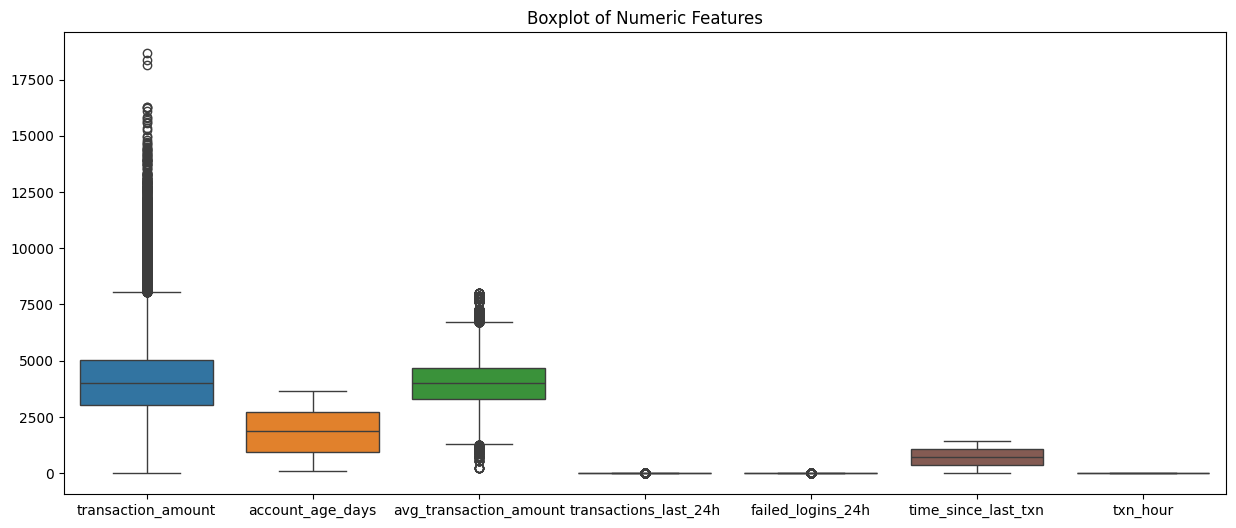

In [15]:
# Boxplot of Numeric Features
plt.figure(figsize=(15,6))
sns.boxplot(data=df[numeric_cols])
plt.title("Boxplot of Numeric Features")
plt.show()

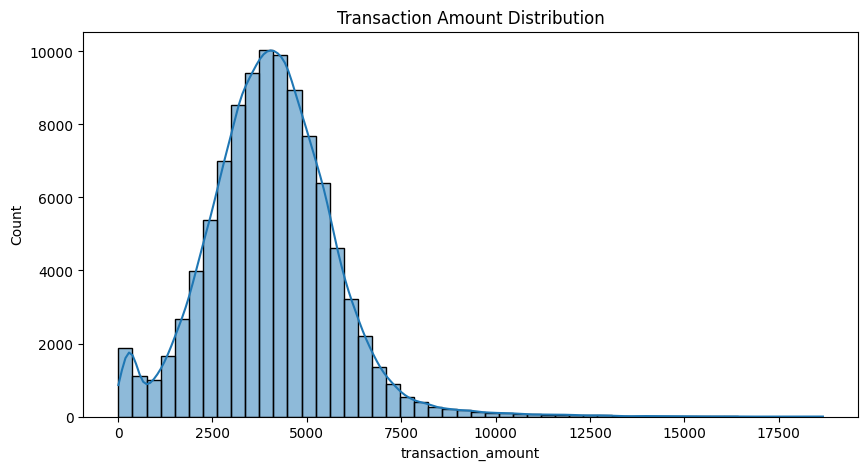

In [16]:
# Distribution of transaction amount
plt.figure(figsize=(10,5))
sns.histplot(df['transaction_amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

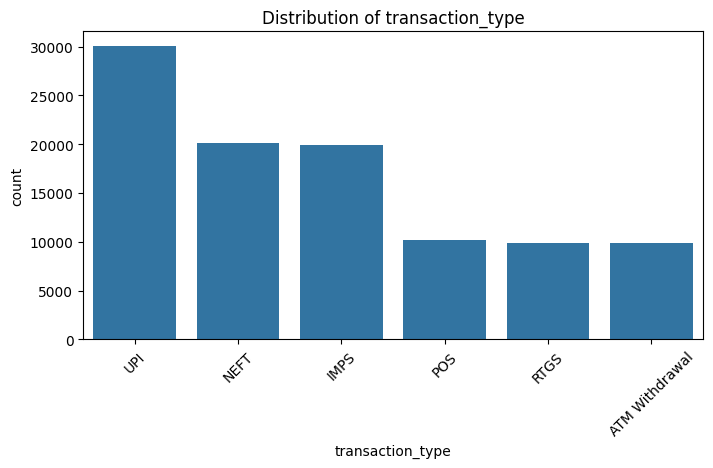

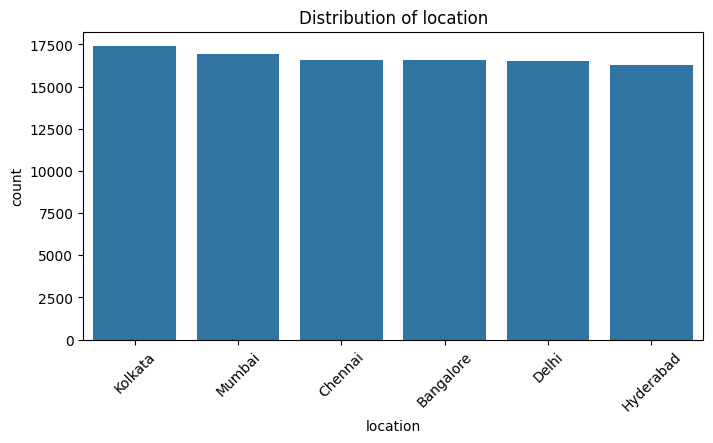

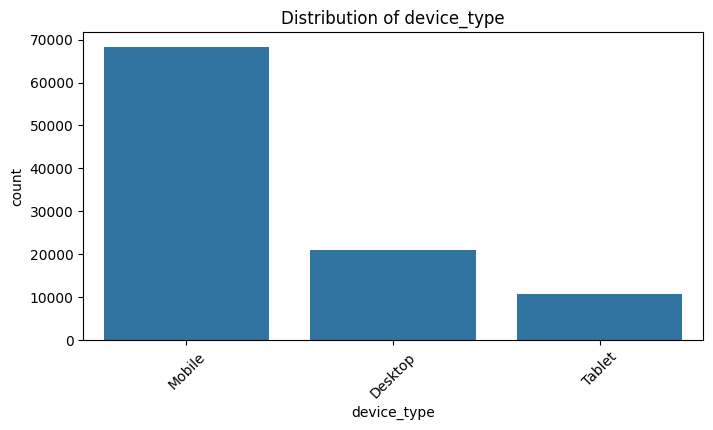

In [17]:
# Categorical Feature Visualization
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

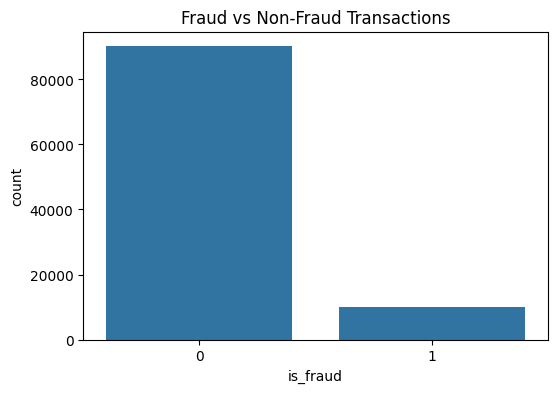

In [18]:
# Fraud Analysis
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


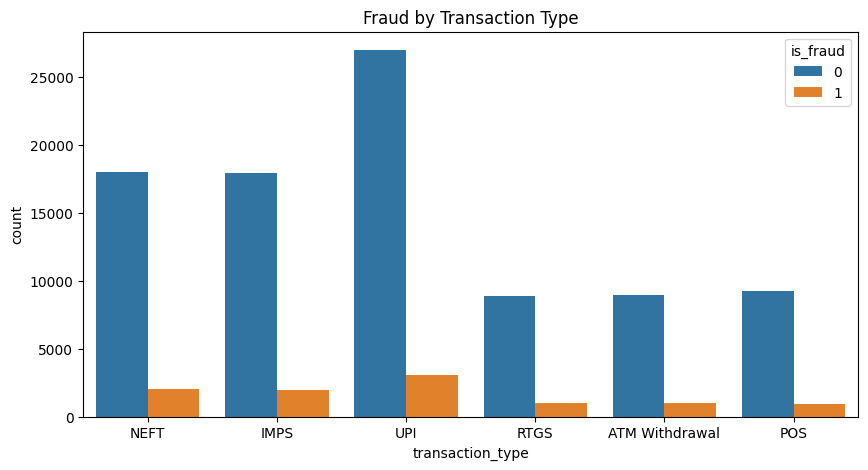

In [19]:
# Fraud by transaction type
plt.figure(figsize=(10,5))
sns.countplot(x='transaction_type', hue='is_fraud', data=df)
plt.title("Fraud by Transaction Type")
plt.show()


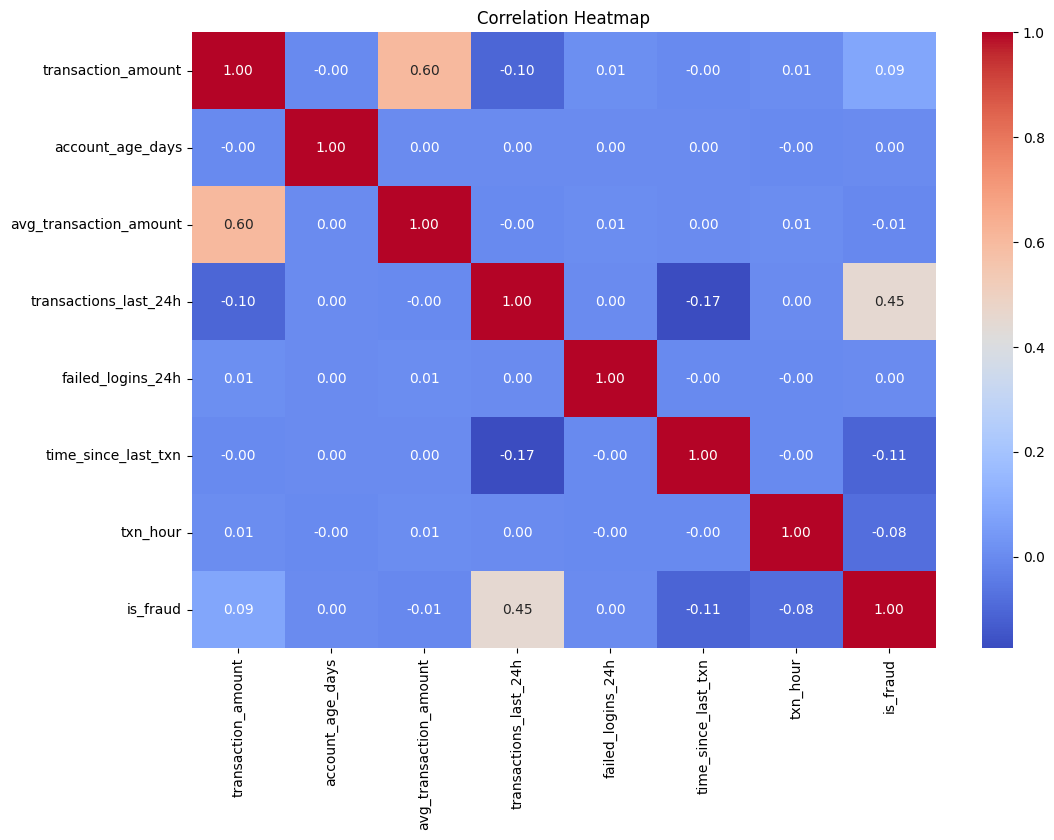

In [20]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols + ['is_fraud']].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [21]:
df_clean = df
df_clean.to_csv("df_clean.csv", index=False)